## Install Needed Packages

In [1]:
%pip -q install --upgrade ydata_profiling


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
from IPython.display import display
from ydata_profiling import ProfileReport
import scipy.stats as st
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from s06e01_experiment_setup import ExperimentSetup
from data_visualization import DataVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'exam_score'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc        7.910            98.800              no   
1   1   18   other  diploma        4.950            94.800             yes   
2   2   20  female     b.sc        4.680            92.600             yes   
3   3   19    male     b.sc        2.000            49.500             yes   
4   4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy   

   exam_score  
0      78.300  
1     

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  gender   course  study_hours  class_attendance  \
0  630000   24   other       ba        6.850            65.200   
1  630001   18    male  diploma        6.610            45.000   
2  630002   24  female   b.tech        6.600            98.500   
3  630003   24    male  diploma        3.030            66.300   
4  630004   20  female   b.tech        2.030            42.400   

  internet_access  sleep_hours sleep_quality study_method facility_rating  \
0             yes        5.200          poor  group study            high   
1              no        9.300          poor     coaching             low   
2             yes        6.200          good  group study          medium   
3             yes        5.700       average        mixed          medium   
4             yes        9.200       average     coaching             low   

  exam_difficulty  
0            easy  
1            easy  
2        moderate  
3        moderate  
4        moderate  


## Exploratory Data Analysis

In a previous Playground Episode, I ran across a report generator that shows histograms, tables of most common values, and various interaction plots.  Even better, it can be used to determine if the test dataset differs from the training set, and if so, how.  I spent hours poring over them, and they helped to determine which columns to concentrate on for feature engineering.  And since it creates an HTML report, it can be viewed outside the notebook, from github, for instance.

In [6]:
# FIXME - Remove after DataVisualizer debug is complete
DO_REPORT = False

if DO_REPORT:
    from ydata_profiling import ProfileReport
    
    # Create the profile report object for the TRAINING data
    training_report = ProfileReport(training_df, title='Training Data')
    
    # Create the profile report object for the TEST data
    test_report = ProfileReport(test_df, title='Test Data')
    
    # Create the comparison report
    # This compares the TEST report *against* the TRAINING report
    train_test_comparison_report = training_report.compare(test_report)
    
    # Save the combined report to an HTML file
    train_test_comparison_report.to_file('training_vs_test_comparison.html')

In [7]:
if DO_REPORT:
    # Display the HTML report in an iframe
    IFrame(src='training_vs_test_comparison.html', width=1000, height=600)

## Data Visualization

### Pair Plots

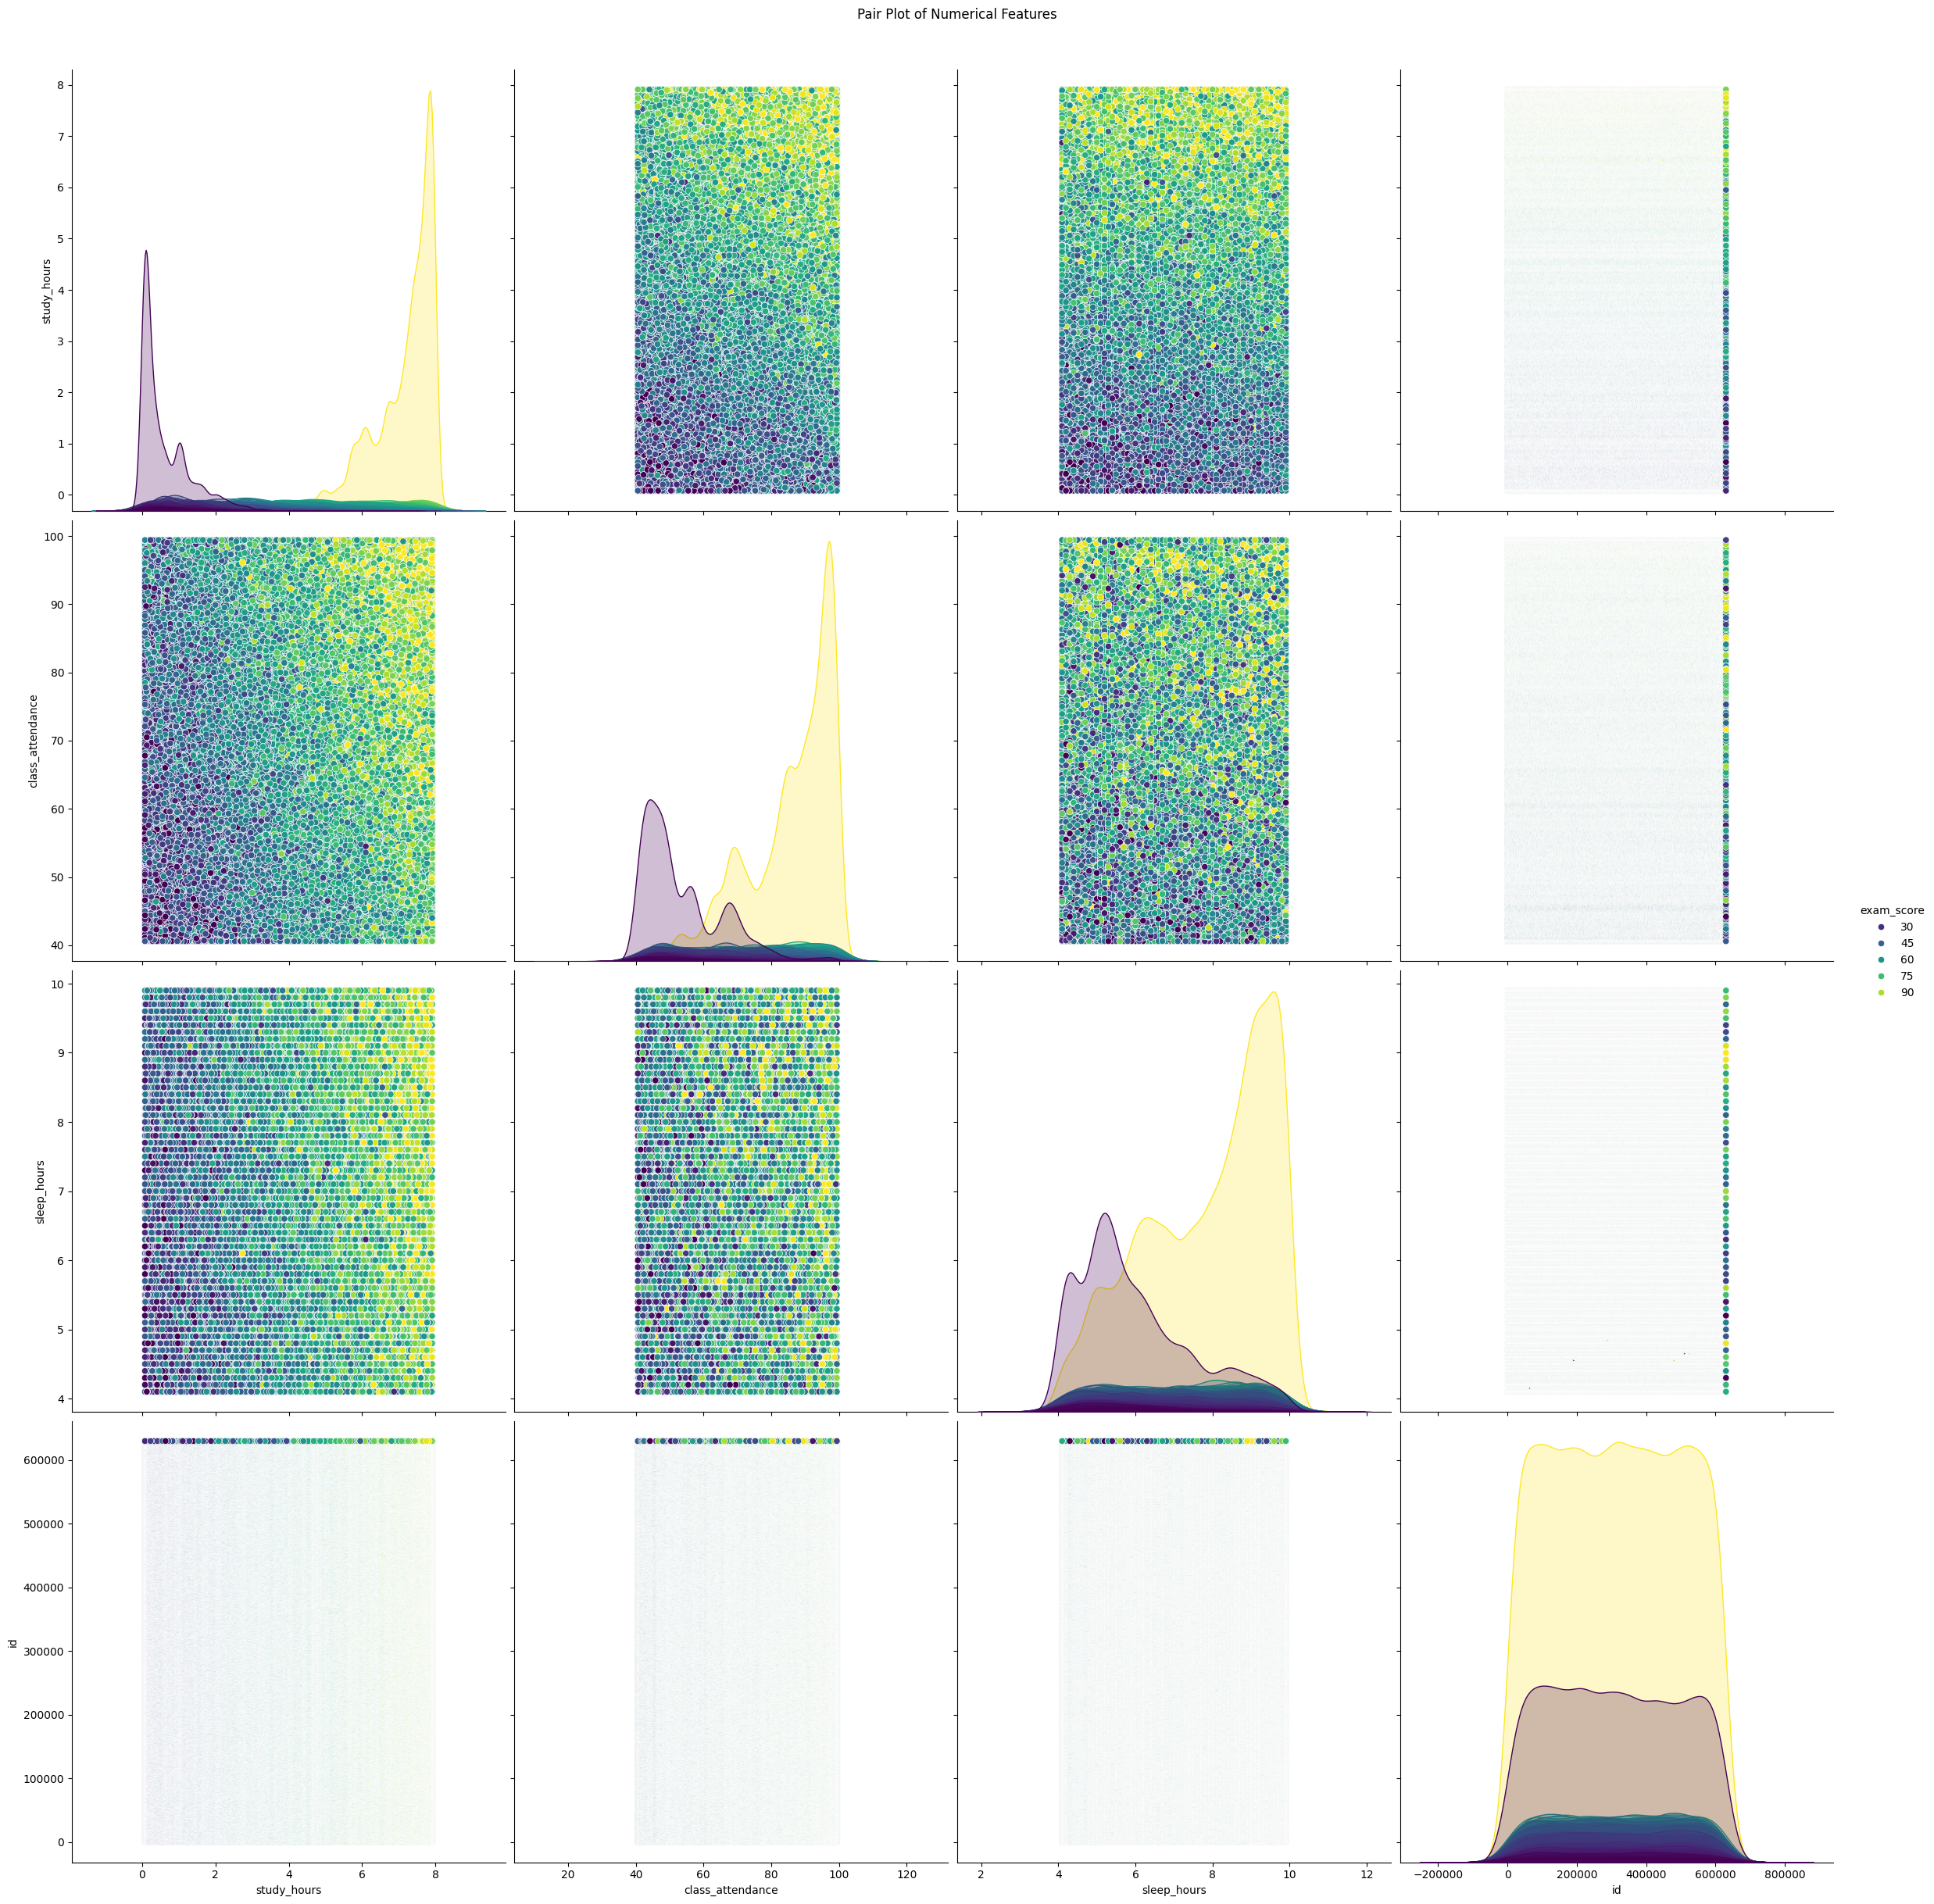

### Violin Plots

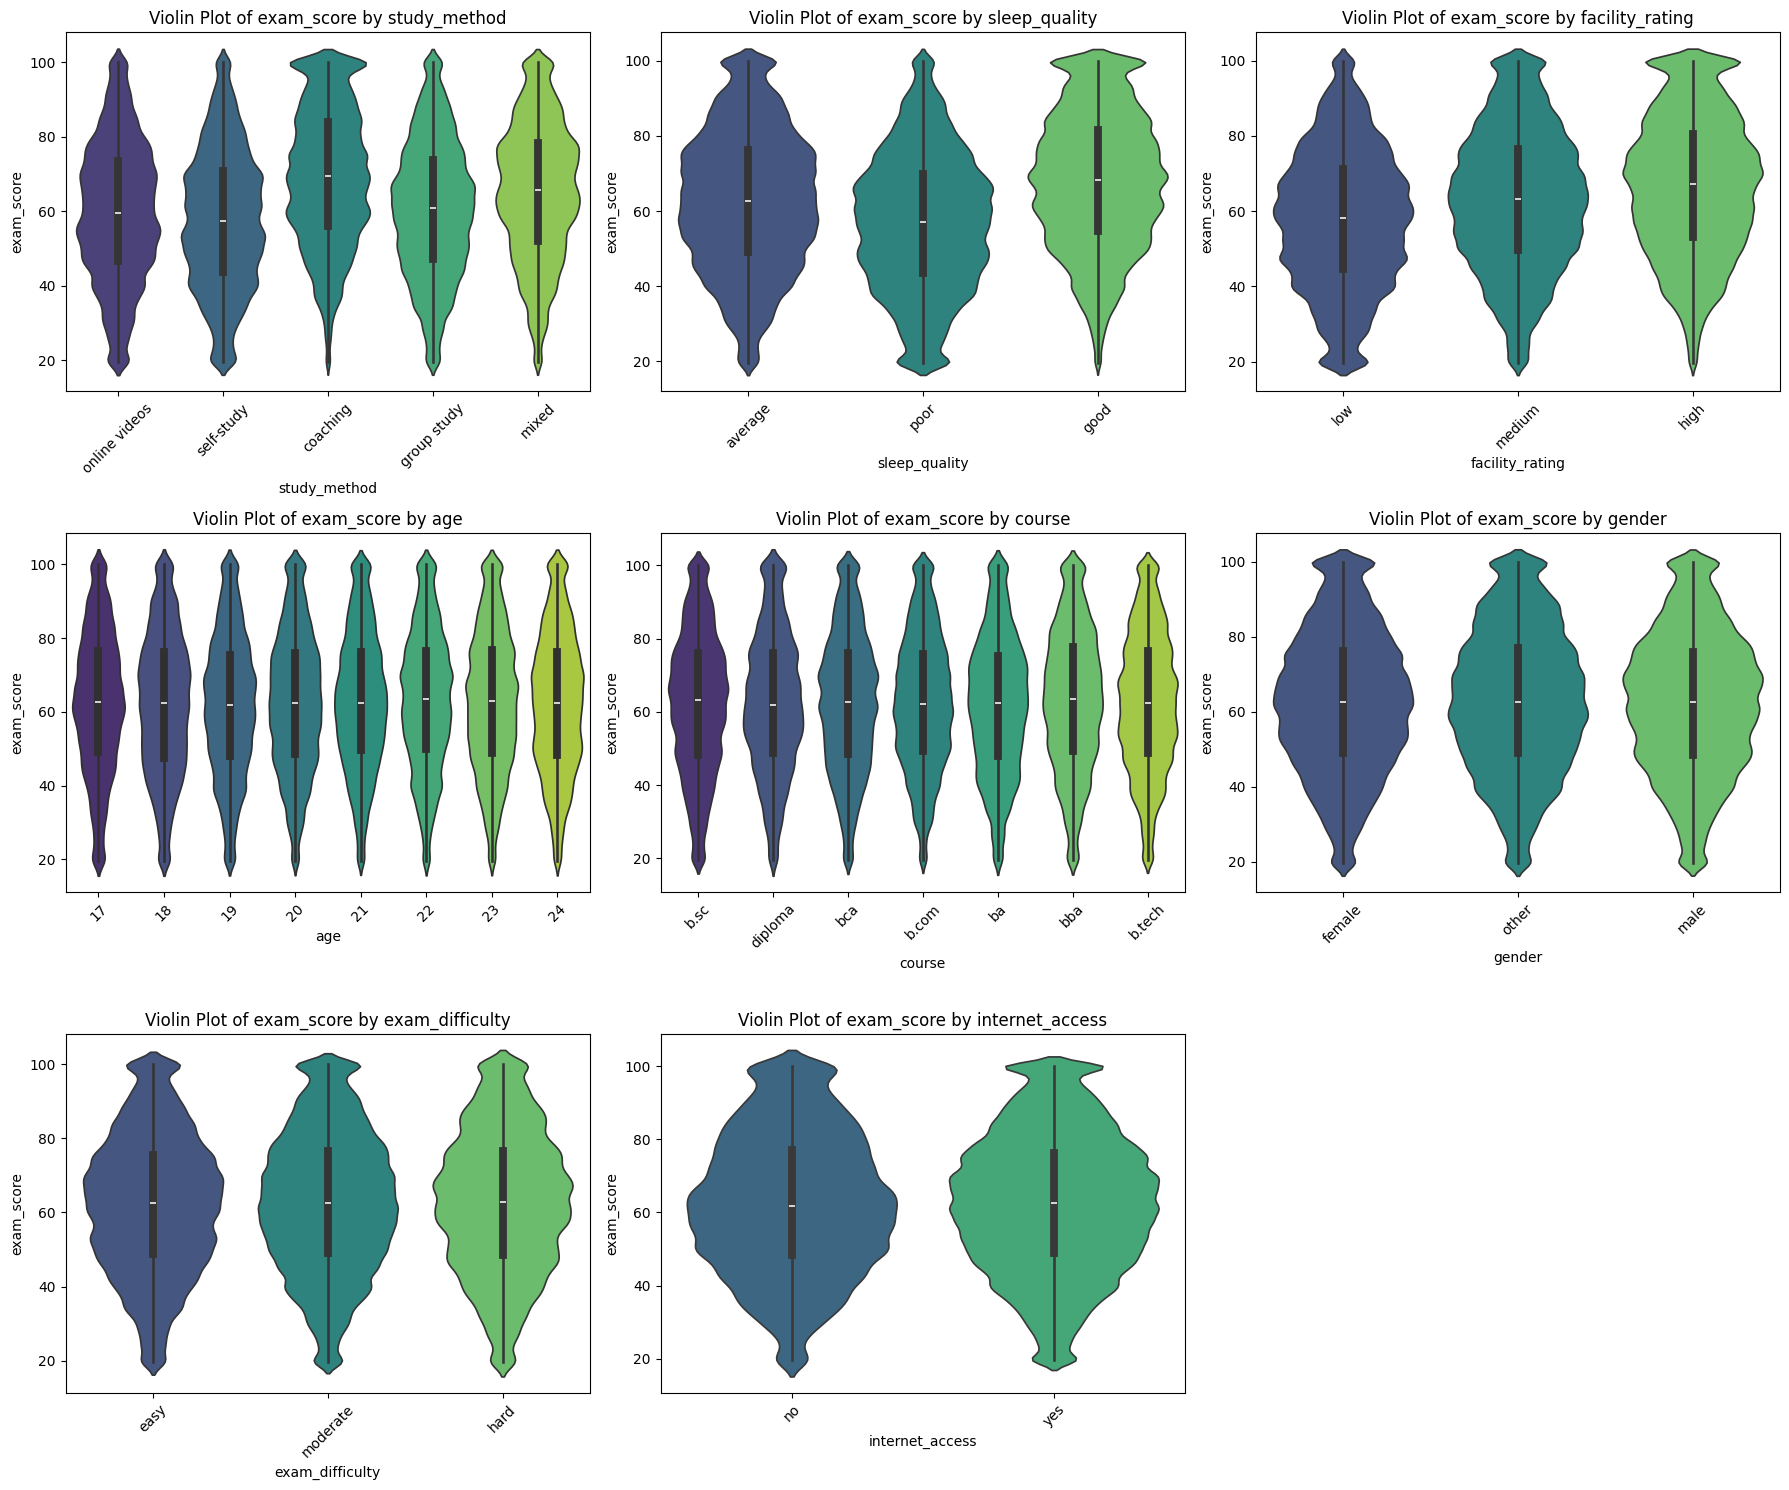

### Numeric × Categorical (Trend By Category)

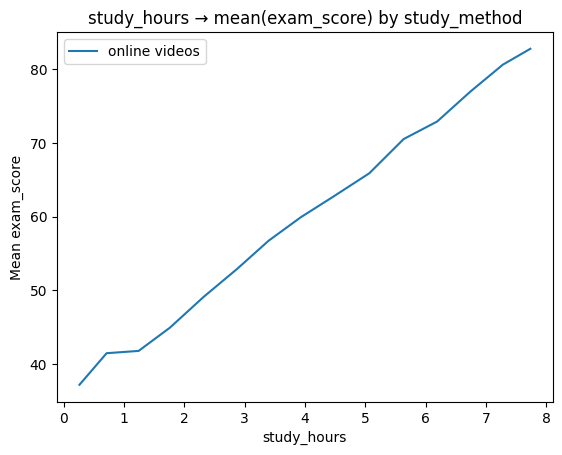

### Categorical × Categorical (Heatmap)

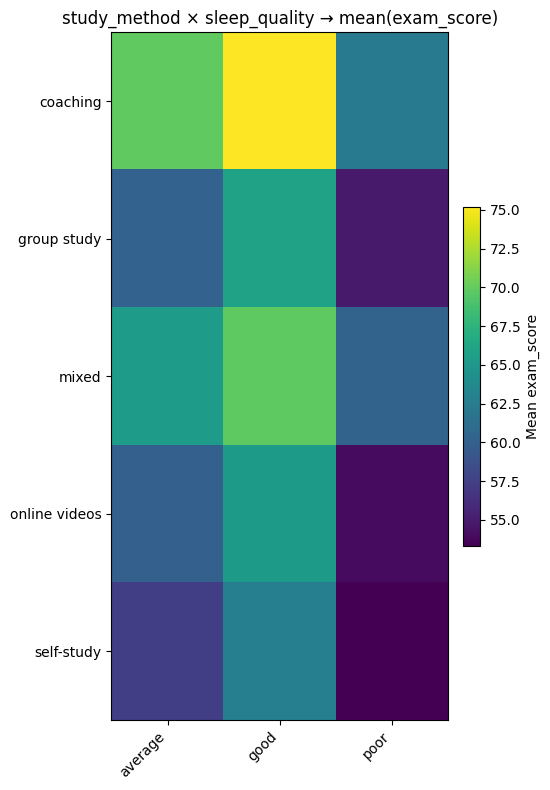

### Numeric × Numeric (Hexbin Target Mean)

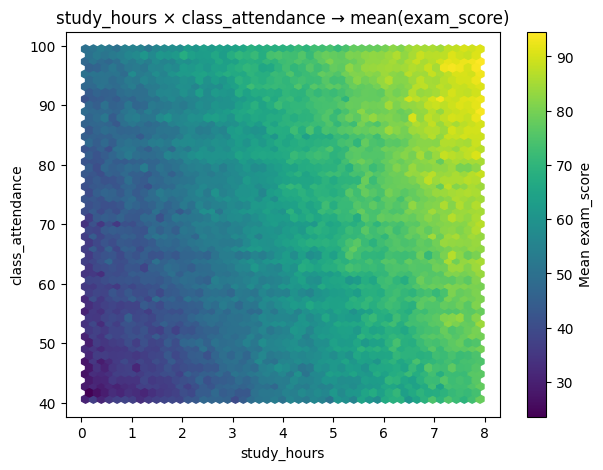

### Feature Signal Ranking

Top numeric (|Spearman|): [('study_hours', 0.7697574865941025), ('class_attendance', 0.35151496194915305), ('sleep_hours', 0.16004792880752652), ('age', 0.007163204282159061), ('id', 0.0002470308783159537)]
Top categorical (range of mean risk): [('study_method', 11.56651068276313, 5), ('sleep_quality', 10.889415648834195, 3), ('facility_rating', 8.752579825578813, 3), ('course', 1.3451069345430327, 7), ('gender', 0.6056298813066263, 3), ('exam_difficulty', 0.45729218727318255, 3), ('internet_access', 0.031134136001860213, 2)]


In [8]:
visualizer = DataVisualizer(target=TARGET, seed=helper.get_seed())
visualizer.run_data_visualization(training_df)